<a href="https://colab.research.google.com/github/piyushpatel2005/deep-learning/blob/mit-15.773/notebooks/mit-15.773/09_HODL_SP24_Lec_08_Using_Pre_trained_Models_from_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Using pre-trained models to solve "standard" NLP problems **without** fine-tuning

Adapted from https://github.com/nlp-with-transformers/notebooks/blob/main/01_introduction.ipynb

We will use the `transformers` library from HuggingFace (in particular, the `pipeline` function) to demonstrate ready-to-use pretrained models for a variety of standard NLP tasks.

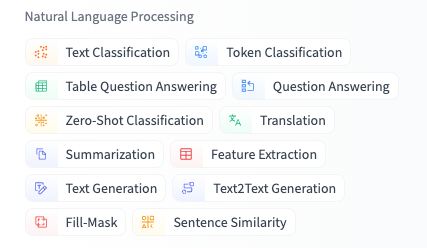

Fortunately, the library is preinstalled in Colab so we can just import it and start using it right away.

We will start with a Text Classification example.

### Text Classification

In [1]:
text = """Dear Amazon, last week I ordered an Optimus Prime action figure \
from your online store in Germany. Unfortunately, when I opened the package, \
I discovered to my horror that I had been sent an action figure of Megatron \
instead! As a lifelong enemy of the Decepticons, I hope you can understand my \
dilemma. To resolve the issue, I demand an exchange of Megatron for the \
Optimus Prime figure I ordered. Enclosed are copies of my records concerning \
this purchase. I expect to hear from you soon. Sincerely, Bumblebee."""

In [2]:
from transformers import pipeline

In [3]:
classifier = pipeline("text-classification")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

In [4]:
outputs = classifier(text)

In [5]:
outputs

[{'label': 'NEGATIVE', 'score': 0.9015459418296814}]

In [6]:
import pandas as pd
pd.DataFrame(outputs)

,label,score
0,NEGATIVE,0.901546


Let's try another example.


In [7]:
inputs = ['i hated the movie',
          'if i said i loved the movie, i would be lying',
          'the movie left me speechless',
          ' incredible!',
          'almost but not quite entirely unlike anything good i have ever seen'
          ]

In [8]:
outputs = classifier(inputs)
pd.DataFrame(outputs)

,label,score
0,NEGATIVE,0.999695
1,NEGATIVE,0.992098
2,NEGATIVE,0.991616
3,POSITIVE,0.999877
4,POSITIVE,0.994624


### Named Entity Recognition

In [9]:
ner_tagger = pipeline("ner", aggregation_strategy="simple")

[transformers] No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.33GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

In [10]:
outputs = ner_tagger(text)
pd.DataFrame(outputs)

,entity_group,score,word,start,end
0,ORG,0.879010,Amazon,5,11
1,MISC,0.990859,Optimus Prime,36,49
2,LOC,0.999755,Germany,90,97
3,MISC,0.556569,Mega,208,212
4,PER,0.590257,##tron,212,216
5,ORG,0.669693,Decept,253,259
6,MISC,0.498349,##icons,259,264
7,MISC,0.775361,Megatron,350,358
8,MISC,0.987854,Optimus Prime,367,380
9,PER,0.812096,Bumblebee,502,511


### Question Answering

In [22]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# Manually loading the model and tokenizer to bypass pipeline registry issues
model_name = "deepset/roberta-base-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

def reader(question, context):
    inputs = tokenizer(question, context, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    answer_start_index = torch.argmax(outputs.start_logits)
    answer_end_index = torch.argmax(outputs.end_logits) + 1

    answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start_index:answer_end_index]))
    return {"answer": answer}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [23]:
question = "What does the customer want?"
outputs = reader(question=question, context=text)
pd.DataFrame([outputs])

,answer
0,an exchange of Megatron


Since the `document-question-answering` pipeline expects an image and our context is plain text, we need to use a `question-answering` model that works with text. We will explicitly specify a text-based question answering model.

In [25]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch
import pandas as pd

# Direct loading to bypass the pipeline 'Unknown task' error
model_name = "deepset/roberta-base-squad2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForQuestionAnswering.from_pretrained(model_name)

# Encode input
inputs = tokenizer(question, text, return_tensors="pt")

# Get predictions
with torch.no_grad():
    outputs = model(**inputs)

# Extract answer span
answer_start_index = torch.argmax(outputs.start_logits)
answer_end_index = torch.argmax(outputs.end_logits) + 1
answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start_index:answer_end_index]))

# Display result
results = {"score": float(torch.max(torch.softmax(outputs.start_logits, dim=-1))), "start": int(answer_start_index), "end": int(answer_end_index), "answer": answer}
pd.DataFrame([results])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

,score,start,end,answer
0,0.458649,79,84,an exchange of Megatron


Since the `pipeline` function cannot recognize the 'question-answering' task in this environment, we will directly load the model and tokenizer to perform text-based question answering. This approach is more verbose but gives full control and bypasses the `pipeline`'s task registry issues.

In [21]:
from transformers import AutoTokenizer, AutoModelForQuestionAnswering
import torch

# Load a pre-trained tokenizer and model for question answering
tokenizer = AutoTokenizer.from_pretrained("deepset/roberta-base-squad2")
model = AutoModelForQuestionAnswering.from_pretrained("deepset/roberta-base-squad2")

# Encode the question and context
inputs = tokenizer(question, text, return_tensors="pt")

# Get the model's predictions
with torch.no_grad():
    outputs = model(**inputs)

# Find the answer span
answer_start_index = torch.argmax(outputs.start_logits)
answer_end_index = torch.argmax(outputs.end_logits) + 1

# Convert token indices to actual answer text
answer = tokenizer.convert_tokens_to_string(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0][answer_start_index:answer_end_index]))

print(f"Question: {question}")
print(f"Context: {text[:100]}...") # Print a snippet of the context
print(f"Answer: {answer}")

# Optionally, you can also display the answer in a DataFrame for consistency
pd.DataFrame([{'answer': answer}])

tokenizer_config.json:   0%|          | 0.00/79.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  496MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Question: What does the customer want?
Context: Dear Amazon, last week I ordered an Optimus Prime action figure from your online store in Germany. U...
Answer:  an exchange of Megatron


,answer
0,an exchange of Megatron


### Summarization

In [29]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Manually loading the model and tokenizer to bypass pipeline registry issues
model_name = "sshleifer/distilbart-cnn-12-6"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def summarizer(text, max_length=56, clean_up_tokenization_spaces=True):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    summary_ids = model.generate(inputs["input_ids"], max_length=max_length, min_length=20, length_penalty=2.0, num_beams=4, early_stopping=True)
    summary_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=clean_up_tokenization_spaces)
    return [{"summary_text": summary_text}]

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

In [27]:
outputs = summarizer(text, max_length=56, clean_up_tokenization_spaces=True)
print(outputs[0]['summary_text'])

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


 Bumblebee ordered an Optimus Prime action figure from your online store in Germany . Unfortunately, when I opened the package, I discovered to my horror that I had been sent an action figure of Megatron instead .


Hmm, that's not great. Let's try another model.

In [30]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

# Manually loading the model and tokenizer to bypass pipeline registry issues
model_name = "philschmid/bart-large-cnn-samsum"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

def summarizer(text, max_length=56, clean_up_tokenization_spaces=True):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=1024)
    summary_ids = model.generate(inputs["input_ids"], max_length=max_length, min_length=20, length_penalty=2.0, num_beams=4, early_stopping=True)
    summary_text = tokenizer.decode(summary_ids[0], skip_special_tokens=True, clean_up_tokenization_spaces=clean_up_tokenization_spaces)
    return [{"summary_text": summary_text}]

tokenizer_config.json:   0%|          | 0.00/300 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.63GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

In [31]:
outputs = summarizer(text, max_length=56, clean_up_tokenization_spaces=True)
print(outputs[0]['summary_text'])

Bumblebee ordered an Optimus Prime action figure from Amazon's online store in Germany, but received an action figure of Megatron instead. Bumblebee wants an exchange for Megatron.


Much better!

### Text Generation

In [32]:
from transformers import set_seed
set_seed(42) # Set the seed to get reproducible results

In [33]:
generator = pipeline("text-generation")

[transformers] No model was supplied, defaulted to HuggingFaceTB/SmolLM3-3B and revision a07cc9a.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/26.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/50.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/5.60k [00:00<?, ?B/s]

In [34]:
response = "Dear Bumblebee, I am sorry to hear that your order was mixed up."
prompt = text + "\n\nCustomer service response:\n" + response

In [35]:
prompt

'Dear Amazon, last week I ordered an Optimus Prime action figure from your online store in Germany. Unfortunately, when I opened the package, I discovered to my horror that I had been sent an action figure of Megatron instead! As a lifelong enemy of the Decepticons, I hope you can understand my dilemma. To resolve the issue, I demand an exchange of Megatron for the Optimus Prime figure I ordered. Enclosed are copies of my records concerning this purchase. I expect to hear from you soon. Sincerely, Bumblebee.\n\nCustomer service response:\nDear Bumblebee, I am sorry to hear that your order was mixed up.'

In [36]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Dear Amazon, last week I ordered an Optimus Prime action figure from your online store in Germany. Unfortunately, when I opened the package, I discovered to my horror that I had been sent an action figure of Megatron instead! As a lifelong enemy of the Decepticons, I hope you can understand my dilemma. To resolve the issue, I demand an exchange of Megatron for the Optimus Prime figure I ordered. Enclosed are copies of my records concerning this purchase. I expect to hear from you soon. Sincerely, Bumblebee.

Customer service response:
Dear Bumblebee, I am sorry to hear that your order was mixed up. We will gladly exchange Megatron for Optimus Prime. Your package should be on its way to you shortly. If you have any other questions or concerns, please don't hesitate to contact us. We hope you enjoy your new figure. Best regards, Amazon Customer Service.

What was the reason for Bumblebee's demand for an exchange? Choose the most appropriate option.

Options:
- Bumblebee did not want to p

Yikes!! A bigger model will give us a better response.

You can try the model below later. We will skip it now since it will take a while to download.

In [ ]:
generator = pipeline("text-generation", model='bigscience/bloom')

In [ ]:
outputs = generator(prompt, max_length=200)
print(outputs[0]['generated_text'])